In [1]:
import pandas as pd
data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")
# filename_data = "weather_prediction_dataset_light.csv"
# data = pd.read_csv(filename_data)
data.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [2]:
data.columns



Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

In [3]:
data.shape


(3654, 91)

In [4]:
nr_rows = 365*3 # 3 years
# data
X_data = data.loc[:nr_rows] # Select first 3 years
X_data = X_data.drop(columns=['DATE', 'MONTH']) # Drop date and month column

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)

In [6]:
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

In [7]:
from tensorflow import keras
keras.utils.set_random_seed(2)

def create_nn(input_shape):
    # Input layer
    inputs = keras.Input(shape=input_shape, name='input')

    # Dense layers
    layers_dense = keras.layers.Dense(100, 'relu')(inputs)
    layers_dense = keras.layers.Dense(50, 'relu')(layers_dense)

    # Output layer
    outputs = keras.layers.Dense(1)(layers_dense)

    return keras.Model(inputs=inputs, outputs=outputs, name="weather_prediction_model")

model = create_nn(input_shape=(X_data.shape[1],))

I0000 00:00:1777765882.168083   61030 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777765882.227152   61030 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777765883.584558   61030 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1777765884.176734   61030 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.summary()

Model: "weather_prediction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,101 (55.08 KB)

 Trainable params: 14,101 (55.08 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='mse')


In [10]:
model.compile(optimizer='adam',
              loss='mse')

In [11]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError()])

In [12]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError()])
compile_model(model)

In [13]:
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    verbose=2)

Epoch 1/200
24/24 - 1s - 27ms/step - loss: 36.4782 - root_mean_squared_error: 6.0397
Epoch 2/200
24/24 - 0s - 3ms/step - loss: 14.6569 - root_mean_squared_error: 3.8284
Epoch 3/200
24/24 - 0s - 3ms/step - loss: 12.7198 - root_mean_squared_error: 3.5665
Epoch 4/200
24/24 - 0s - 4ms/step - loss: 11.8917 - root_mean_squared_error: 3.4484
Epoch 5/200
24/24 - 0s - 3ms/step - loss: 11.7109 - root_mean_squared_error: 3.4221
Epoch 6/200
24/24 - 0s - 3ms/step - loss: 11.3805 - root_mean_squared_error: 3.3735
Epoch 7/200
24/24 - 0s - 3ms/step - loss: 11.0844 - root_mean_squared_error: 3.3293
Epoch 8/200
24/24 - 0s - 3ms/step - loss: 10.9668 - root_mean_squared_error: 3.3116
Epoch 9/200
24/24 - 0s - 3ms/step - loss: 10.8308 - root_mean_squared_error: 3.2910
Epoch 10/200
24/24 - 0s - 3ms/step - loss: 10.6547 - root_mean_squared_error: 3.2641
Epoch 11/200
24/24 - 0s - 3ms/step - loss: 10.5066 - root_mean_squared_error: 3.2414
Epoch 12/200
24/24 - 0s - 3ms/step - loss: 10.3614 - root_mean_squared_er

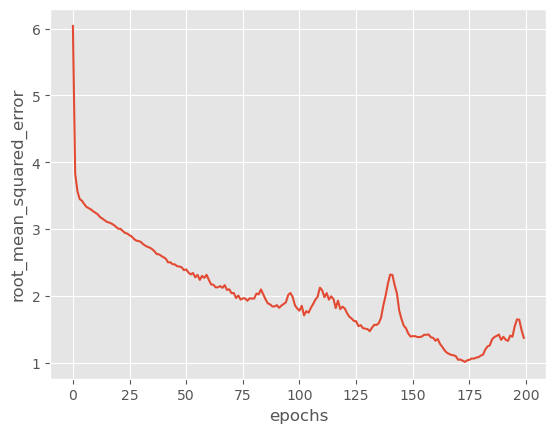

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics (str, list): Metric or a list of metrics to plot
    """
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")

plot_history(history, 'root_mean_squared_error')


In [15]:
y_train_predicted = model.predict(X_train)
y_test_predicted = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


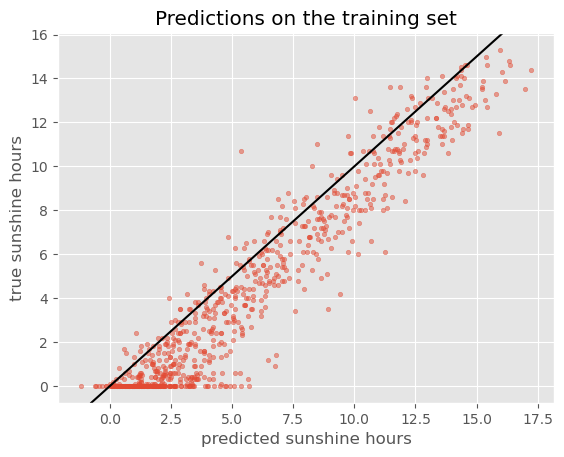

In [16]:
# We define a function that we will reuse in this lesson
def plot_predictions(y_pred, y_true, title):
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    plt.scatter(y_pred, y_true, s=10, alpha=0.5)
    plt.axline((0,0),slope = 1, color = "black") # plot diagonal reference line
    plt.xlabel("predicted sunshine hours")
    plt.ylabel("true sunshine hours")
    plt.title(title)

plot_predictions(y_train_predicted, y_train, title='Predictions on the training set')

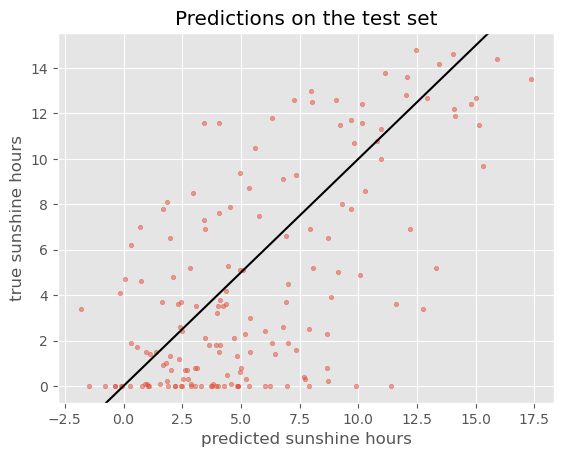

In [17]:
plot_predictions(y_test_predicted, y_test, title='Predictions on the test set')

In [18]:
train_metrics = model.evaluate(X_train, y_train, return_dict=True)
test_metrics = model.evaluate(X_test, y_test, return_dict=True)
print('Train RMSE: {:.2f}, Test RMSE: {:.2f}'.format(train_metrics['root_mean_squared_error'], test_metrics['root_mean_squared_error']))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3541 - root_mean_squared_error: 1.8314 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.9281 - root_mean_squared_error: 3.8637 
Train RMSE: 1.83, Test RMSE: 3.86


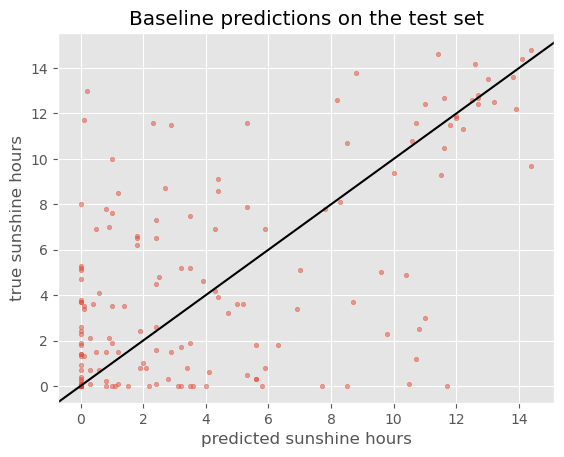

In [19]:
y_baseline_prediction = X_test['BASEL_sunshine']
plot_predictions(y_baseline_prediction, y_test, title='Baseline predictions on the test set')

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_baseline = mean_squared_error(y_test, y_baseline_prediction, squared=False)
print('Baseline:', rmse_baseline)
print('Neural network: ', test_metrics['root_mean_squared_error'])


Baseline: 3.877323350410224
Neural network:  3.8636889457702637


In [21]:
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

In [22]:
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_data=(X_val, y_val))

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 20.5121 - root_mean_squared_error: 4.5290 - val_loss: 14.8430 - val_root_mean_squared_error: 3.8527
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.7529 - root_mean_squared_error: 3.5711 - val_loss: 11.5805 - val_root_mean_squared_error: 3.4030
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.9020 - root_mean_squared_error: 3.4499 - val_loss: 11.4841 - val_root_mean_squared_error: 3.3888
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5304 - root_mean_squared_error: 3.3956 - val_loss: 11.1623 - val_root_mean_squared_error: 3.3410
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.2362 - root_mean_squared_error: 3.3520 - val_loss: 11.1847 - val_root_mean_squared_error: 3.3444
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.0004 - root_mean_squared_error: 3.3167 - val_loss: 11.0727 - val_root_mean_squared_error: 3.3276
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

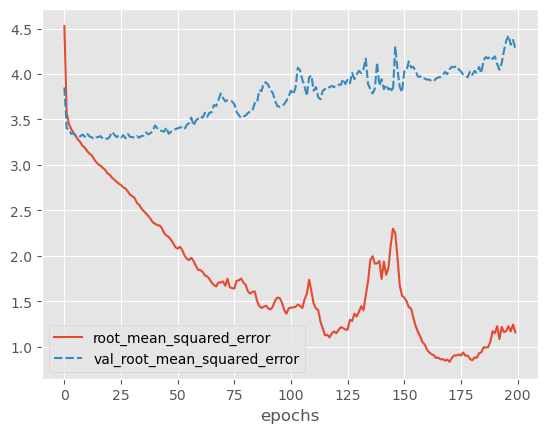

In [23]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [24]:
def create_nn(input_shape, nodes1=100, nodes2=50):
   # Input layer
   inputs = keras.layers.Input(shape=input_shape, name='input')
   # Dense layers
   layers_dense = keras.layers.Dense(nodes1, 'relu')(inputs)
   layers_dense = keras.layers.Dense(nodes2, 'relu')(layers_dense)
   # Output layer
   outputs = keras.layers.Dense(1)(layers_dense)
   return keras.Model(inputs=inputs, outputs=outputs, name="model_small")
    

In [25]:
model = create_nn(input_shape=(X_data.shape[1],), nodes1=10, nodes2=5)
model.summary()

Model: "model_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 19.7589 - root_mean_squared_error: 4.4451 - val_loss: 15.5809 - val_root_mean_squared_error: 3.9473
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.0703 - root_mean_squared_error: 4.0088 - val_loss: 15.2012 - val_root_mean_squared_error: 3.8989
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.8817 - root_mean_squared_error: 3.8577 - val_loss: 14.7487 - val_root_mean_squared_error: 3.8404
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.2376 - root_mean_squared_error: 3.7733 - val_loss: 14.2697 - val_root_mean_squared_error: 3.7775
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.9041 - root_mean_squared_error: 3.7288 - val_loss: 14.0498 - val_root_mean_squared_error: 3.7483
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.4997 - root_mean_squared_error: 3.6742 - val_loss: 13.8576 - val_root_mean_squared_error: 3.7226
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

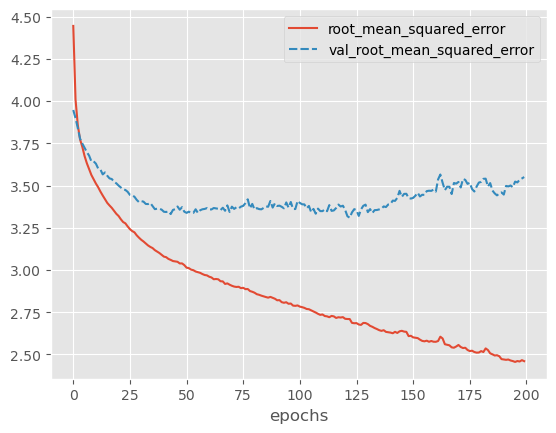

In [26]:
compile_model(model)
history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 200,
                   validation_data=(X_val, y_val))
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [31]:
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

earlystopper = EarlyStopping(
    monitor='val_loss',
    patience=10
    )

history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 200,
                    validation_data=(X_val, y_val),
                    callbacks=[earlystopper])

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 25.4925 - root_mean_squared_error: 5.0490 - val_loss: 154.9561 - val_root_mean_squared_error: 12.4481
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.9821 - root_mean_squared_error: 3.8707 - val_loss: 52.4199 - val_root_mean_squared_error: 7.2402
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.6880 - root_mean_squared_error: 3.5620 - val_loss: 38.5176 - val_root_mean_squared_error: 6.2063
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5141 - root_mean_squared_error: 3.3932 - val_loss: 26.8442 - val_root_mean_squared_error: 5.1811
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.7694 - root_mean_squared_error: 3.2817 - val_loss: 20.2230 - val_root_mean_squared_error: 4.4970
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.2783 - root_mean_squared_error: 3.2060 - val_loss: 16.4067 - val_root_mean_squared_error: 4.0505
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

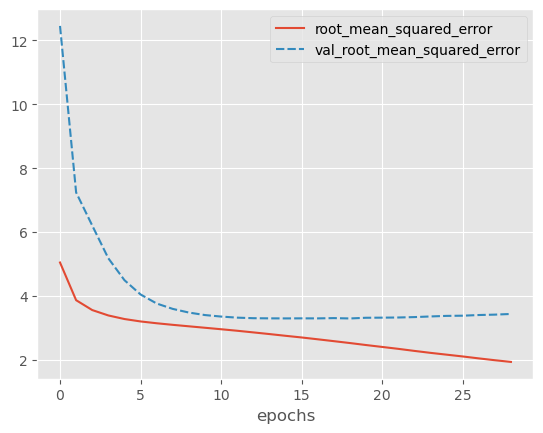

In [33]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [34]:
def create_nn(input_shape):
    # Input layer
    inputs = keras.layers.Input(shape=input_shape, name='input')

    # Dense layers
    layers_dense = keras.layers.BatchNormalization()(inputs) # This is new!
    layers_dense = keras.layers.Dense(100, 'relu')(layers_dense)
    layers_dense = keras.layers.Dense(50, 'relu')(layers_dense)

    # Output layer
    outputs = keras.layers.Dense(1)(layers_dense)

    # Defining the model and compiling it
    return keras.Model(inputs=inputs, outputs=outputs, name="model_batchnorm")

model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)
model.summary()

Model: "model_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 89)             │           356 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,457 (56.47 KB)

 Trainable params: 14,279 (55.78 KB)

 Non-trainable params: 178 (712.00 B)

Epoch 1/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 18.3091 - root_mean_squared_error: 4.2789 - val_loss: 259.3827 - val_root_mean_squared_error: 16.1054
Epoch 2/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.1766 - root_mean_squared_error: 3.6300 - val_loss: 73.8284 - val_root_mean_squared_error: 8.5923
Epoch 3/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5762 - root_mean_squared_error: 3.4024 - val_loss: 40.6446 - val_root_mean_squared_error: 6.3753
Epoch 4/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.6916 - root_mean_squared_error: 3.2698 - val_loss: 27.8825 - val_root_mean_squared_error: 5.2804
Epoch 5/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.1838 - root_mean_squared_error: 3.1912 - val_loss: 21.0689 - val_root_mean_squared_error: 4.5901
Epoch 6/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7821 - root_mean_squared_error: 3.1276 - val_loss: 17.1836 - val_root_mean_squared_error: 4.1453
Epoch 7/1000
24/24 ━━━━━━━━━━━━━━━━━━━━

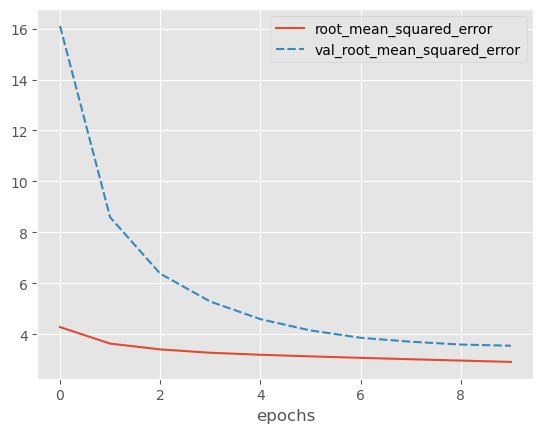

In [35]:
history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 1000,
                    validation_data=(X_val, y_val),
                    callbacks=[earlystopper])

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


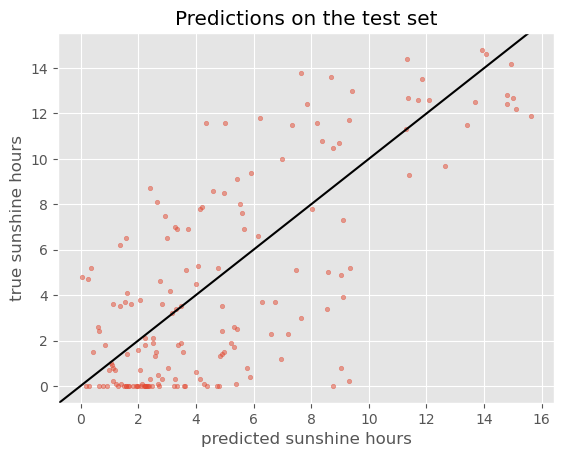

In [36]:
y_test_predicted = model.predict(X_test)
plot_predictions(y_test_predicted, y_test, title='Predictions on the test set')

In [37]:
## Exercise: Simplify the model and add data
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]



In [38]:
nr_rows = 365*9
# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [39]:
# only use columns with 'BASEL'
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [40]:
X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

In [41]:
# create the network and view its summary
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)
model.summary()

Model: "model_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 9)              │            36 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,137 (23.97 KB)

 Trainable params: 6,119 (23.90 KB)

 Non-trainable params: 18 (72.00 B)

Epoch 1/1000
72/72 - 1s - 15ms/step - loss: 20.0229 - root_mean_squared_error: 4.4747 - val_loss: 25.6198 - val_root_mean_squared_error: 5.0616
Epoch 2/1000
72/72 - 0s - 3ms/step - loss: 12.7783 - root_mean_squared_error: 3.5747 - val_loss: 15.4598 - val_root_mean_squared_error: 3.9319
Epoch 3/1000
72/72 - 0s - 3ms/step - loss: 12.1356 - root_mean_squared_error: 3.4836 - val_loss: 13.6026 - val_root_mean_squared_error: 3.6882
Epoch 4/1000
72/72 - 0s - 3ms/step - loss: 11.8150 - root_mean_squared_error: 3.4373 - val_loss: 12.8904 - val_root_mean_squared_error: 3.5903
Epoch 5/1000
72/72 - 0s - 3ms/step - loss: 11.6273 - root_mean_squared_error: 3.4099 - val_loss: 12.4888 - val_root_mean_squared_error: 3.5339
Epoch 6/1000
72/72 - 0s - 3ms/step - loss: 11.4986 - root_mean_squared_error: 3.3910 - val_loss: 12.2136 - val_root_mean_squared_error: 3.4948
Epoch 7/1000
72/72 - 0s - 3ms/step - loss: 11.4055 - root_mean_squared_error: 3.3772 - val_loss: 11.9927 - val_root_mean_squared_error: 3.463

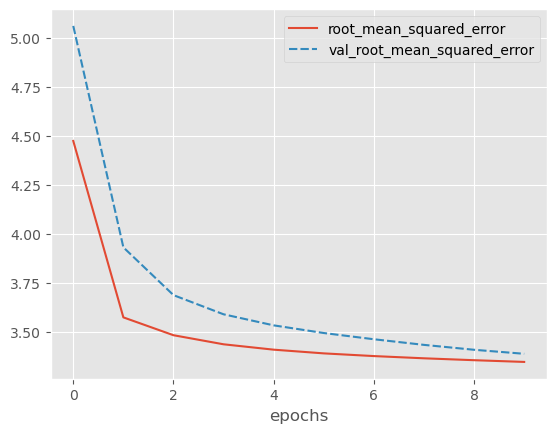

In [42]:
history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 1000,
                   validation_data=(X_val, y_val),
                   callbacks=[earlystopper],
                   verbose = 2)
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


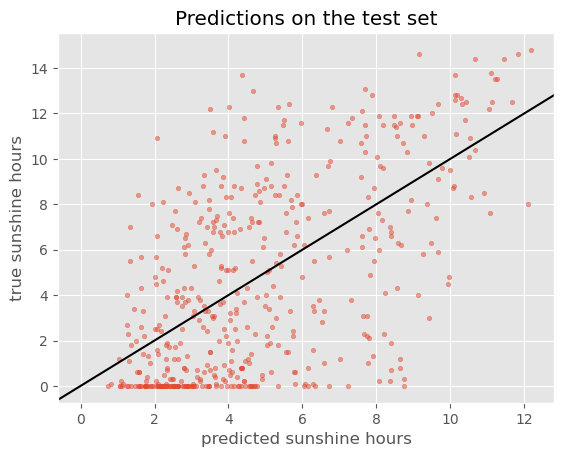

In [43]:
y_test_predicted = model.predict(X_test)
plot_predictions(y_test_predicted, y_test, title='Predictions on the test set')

In [44]:
test_metrics = model.evaluate(X_test, y_test, return_dict=True)
print(f'Test RMSE: {test_metrics["root_mean_squared_error"]}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.4951 - root_mean_squared_error: 3.3904 
Test RMSE: 3.390437126159668


In [45]:
# We cannot take all rows, because we need to be able to take the sunshine hours of the next day
nr_rows = len(data) - 2

# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [49]:
from tensorflow.keras.callbacks import TensorBoard
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") # You can adjust this to add a more meaningful model name
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 200,
                   validation_data=(X_val, y_val),
                   callbacks=[tensorboard_callback],
                   verbose = 2)


Epoch 1/200
72/72 - 0s - 5ms/step - loss: 11.1637 - root_mean_squared_error: 3.3412 - val_loss: 11.3718 - val_root_mean_squared_error: 3.3722
Epoch 2/200
72/72 - 0s - 3ms/step - loss: 11.1062 - root_mean_squared_error: 3.3326 - val_loss: 11.3316 - val_root_mean_squared_error: 3.3662
Epoch 3/200
72/72 - 0s - 3ms/step - loss: 11.0659 - root_mean_squared_error: 3.3265 - val_loss: 11.2872 - val_root_mean_squared_error: 3.3596
Epoch 4/200
72/72 - 0s - 3ms/step - loss: 11.0256 - root_mean_squared_error: 3.3205 - val_loss: 11.2548 - val_root_mean_squared_error: 3.3548
Epoch 5/200
72/72 - 0s - 3ms/step - loss: 10.9901 - root_mean_squared_error: 3.3151 - val_loss: 11.2342 - val_root_mean_squared_error: 3.3518
Epoch 6/200
72/72 - 0s - 3ms/step - loss: 10.9608 - root_mean_squared_error: 3.3107 - val_loss: 11.2077 - val_root_mean_squared_error: 3.3478
Epoch 7/200
72/72 - 0s - 3ms/step - loss: 10.9300 - root_mean_squared_error: 3.3061 - val_loss: 11.1895 - val_root_mean_squared_error: 3.3451
Epoch 

In [59]:
import os
os.environ["PATH"] += ":/home/jovyan/.local/bin"

In [60]:
!pwd

/home/jovyan/intro-to-deep-learning-carpentries-lab/episodes


In [61]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [62]:
%tensorboard --logdir /logs/fit/20260502-235933 #--load_fast=false

In [58]:
#!kill 514867
